# Deep Unfolded Levenberg–Marquardt (LM)

In this notebook, we simulate the application of deep unfolding to optimize the iteration-dependent damping parameter λ (lambda) used in the Levenberg–Marquardt algorithm. Our goal is to improve the estimation of the parameters of a noisy Gaussian signal by learning the best factors (alpha) by wich lambda updates across iterations.


## Setup
We consider a Gaussian profile + WGN setup. To that aim, we generate a data set $\mathcal{D}=\{(\boldsymbol{g(x})^i, \boldsymbol{s}^i)\}_{i=1}^{n_t}$, where each $\boldsymbol{g}^i $ has $n=100$ entries , while $\boldsymbol{s}^i$ has $m=3$ entires :

$\boldsymbol{s}^i=[A,\mu,σ_s]: A\in [1,10], \mu\in [-1,1], σ_s\in [0.1,1].$	   

\begin{equation}
\boldsymbol{g}^i =\frac{A}{\sqrt{2\piσ_s^2}}e^{\frac{-(\boldsymbol{x}-\mu)^2}{2σ_s^2}}+ \boldsymbol{v}^i,
\end{equation}

with $\boldsymbol{v}^i$ being i.i.d. Gaussian noise, $\boldsymbol{v}^i$~$N(0,σ_v^2)$.

In [ ]:
import torch, numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.utils.data as Data
import matplotlib.pyplot as plt
import math


SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

torch.set_default_dtype(torch.float32)

In [ ]:
class SimulatedData(Data.Dataset):
    def __init__(self, x, s):
        self.x = x  # Shape: (N, n)
        self.s = s  # Shape: (N, 3)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        x_i = self.x[idx, :]
        s_i = self.s[idx, :]
        return x_i, s_i



the next function were used accross this notebook to calculate jacobian, gaussain profile, and residuals

In [ ]:
def jacobian(x, params, eps=1e-6):
    """
    Compute Jacobian matrix using finite differences.

    Args:
        x: (n,) or (batch_size, n) - x values where function is evaluated
        params: (batch_size, m) - parameters [A, mu, sigma] for each batch item
        eps: finite difference step size

    Returns:
        J: (batch_size, n, m) - Jacobian matrix
    """
    # Ensure params is 2D
    if params.dim() == 1:
        params = params.unsqueeze(0)  # Handle single sample case

    batch_size, m = params.shape

    # Handle x with or without batch dimension
    if x.dim() == 1:
        n = len(x)
        x_batch = x.unsqueeze(0).repeat(batch_size, 1)  # (batch_size, n)
    else:
        batch_size_x, n = x.shape
        if batch_size_x != batch_size:
            raise ValueError(f"Batch size mismatch: x has {batch_size_x}, params has {batch_size}")
        x_batch = x

    # Initialize Jacobian tensor
    J = torch.zeros(batch_size, n, m, dtype=x.dtype, device=x.device)

    # Compute base function values
    f0 = true_gaussian(x_batch, params[:, 0], params[:, 1], params[:, 2])  # (batch_size, n)

    # Compute partial derivatives for each parameter
    for i in range(m):
        # Perturb parameter i
        p_eps = params.clone()
        p_eps[:, i] += eps

        # Compute perturbed function values
        fi = true_gaussian(x_batch, p_eps[:, 0], p_eps[:, 1], p_eps[:, 2])  # (batch_size, n)

        # Finite difference approximation
        J[:, :, i] = (fi - f0) / eps

    return J
def true_gaussian(x, A, mu, sigma):
    """
    Computes Gaussian signals.

    Parameters:
    - x: shape (n,) or (batch_size, n)
    - A, mu, sigma: scalar or shape (batch_size,)

    Returns:
    - Gaussian signal(s): shape (n,) or (batch_size, n)
    """
    # Convert scalars to tensors
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    if not torch.is_tensor(A):
        A = torch.tensor(A, dtype=torch.float32)
    if not torch.is_tensor(mu):
        mu = torch.tensor(mu, dtype=torch.float32)
    if not torch.is_tensor(sigma):
        sigma = torch.tensor(sigma, dtype=torch.float32)

    # Handle single signal case: x.shape = (n,), A, mu, sigma are scalars
    if x.dim() == 1:
        return A / (torch.sqrt(torch.tensor(2 * torch.pi)) * sigma) * \
               torch.exp(-0.5 * ((x - mu) / sigma) ** 2)

    # Batched case: x.shape = (batch_size, n), A, mu, sigma = (batch_size,)
    return A[:, None] / (torch.sqrt(torch.tensor(2 * torch.pi)) * sigma[:, None]) * \
           torch.exp(-0.5 * ((x - mu[:, None]) / sigma[:, None]) ** 2)


def residuals(x, params,y):
    tg=true_gaussian(x, params[:, 0], params[:, 1], params[:, 2])
    return y-tg




'    \nx_exm, s_exm = test_loader.dataset.__getitem__(0) \ninitial_params = torch.tensor([5.5, 0, 0.55])\nx_axis = torch.linspace(-4, 4, n)\nif initial_params.dim() == 1:\n  initial_params = initial_params.unsqueeze(0).repeat(1, 1)\nparams=initial_params.clone()\nr=residuals(x_axis.unsqueeze(0), params,x_exm.unsqueeze(0))\n'

In [ ]:
def create_data_set(n=100, N=1000, batch_size=256, sigma_v=0.5):
    # Create fixed x-axis: 100 points between -4 and 4
    x_axis = torch.linspace(-4, 4, n).unsqueeze(0).repeat(N, 1)
    # Initialize signal and noise containers
    x = torch.zeros(N, n)
    s = torch.zeros(N, 3)  # Each row is [A, mu, sigma_s]
    noise=torch.zeros(N,n)
    for i in range(N):
        # Sample s_i = [A, mu, sigma_s]
        A = np.random.uniform(1, 10)
        mu = np.random.uniform(-1, 1)
        sigma_s = np.random.uniform(0.1, 1)

        # Store s_i
        s[i, :] = torch.tensor([A, mu, sigma_s], dtype=torch.float32)



    # Generate noisy Gaussian profile

    g_profile = true_gaussian(x_axis, s[:,0], s[:,1], s[:,2])
    noise = sigma_v * torch.randn(N, n)
    x=g_profile+noise

    dataset = SimulatedData(x=x, s=s)
    data_loader = Data.DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    return data_loader


In [ ]:
n = 100  # number of points every x^i
N = 1000  # number of x^i samples

train_loader = create_data_set(n=n, N=N)
test_loader = create_data_set(n=n, N=N)



## LM-algorithem
We apply LM here to the Least Squares Error objective function
\begin{equation}
	     S_{\rm }({\boldsymbol x}) = \mathop{\arg\min}\limits_{\boldsymbol s}
			 \sum{\|\boldsymbol g(x)}-{\boldsymbol f(x,s)}\|^2
\end{equation}
Where $\boldsymbol f(x,s)$ is the fitted curve.

Thus, the objective parameter is
	\begin{equation}
	    {\boldsymbol \theta}^{\rm o} = \{\boldsymbol {s}=[A,\mu,σ_s]\}.
	\end{equation}

  LM can solve an objective of this form by alternations of the form
 $$
			\boldsymbol{s}^{(k+1)} \leftarrow \boldsymbol{s}^{(k)}  -({\boldsymbol{J^T}\boldsymbol{J}+\lambda \boldsymbol{I})^{-1}}\boldsymbol{J^T}
		({\boldsymbol g(x)}-{\boldsymbol f(x,s^{(k)})})$$

  

where $\boldsymbol{J}$ is the Jacobian matrix of $\boldsymbol{f}$ with respect of ${\boldsymbol \theta}^{\rm o}$.



In [ ]:
def levenberg_marquardt(x, y, initial_params, max_iter=11, tol=1e-12, lambda_init=1e-2):
    '''
    x: (batch_size, n)
    y: (batch_size, n)
    initial_params: (m,) or (batch_size, m) [A, mu, sigma]
    '''

    # Handle single initial param vector
    if initial_params.dim() == 1:
        initial_params = initial_params.unsqueeze(0).repeat(x.shape[0], 1)

    batch_size, m = initial_params.shape
    params = initial_params.clone()

    lamb = lambda_init * torch.ones(batch_size, 1, 1, device=params.device)

    for i in range(max_iter):

        r = residuals(x, params, y)  # (batch_size, n)
        cost = torch.sum(r ** 2, dim=1, keepdim=True)  # (batch_size, 1)

        J = jacobian(x, params)  # (batch_size, n, m)
        JT = J.transpose(1, 2)   # (batch_size, m, n)
        H = JT @ J               # (batch_size, m, m)
        g = JT @ r.unsqueeze(-1)  # (batch_size, m, 1)

        I = torch.eye(m, device=params.device).unsqueeze(0).repeat(batch_size, 1, 1)

        delta = torch.zeros_like(params)
        success = torch.ones(batch_size, dtype=torch.bool)

        for b in range(batch_size):
            try:
                H_lm = H[b] + lamb[b] * I[b]
                delta_b = torch.linalg.solve(H_lm, g[b])  # (m, 1)
                delta[b] = delta_b.squeeze(-1)
            except torch.linalg.LinAlgError:
                success[b] = False

        new_params = params + delta
        new_r = residuals(x, new_params, y)
        new_cost = torch.sum(new_r ** 2, dim=1, keepdim=True)

        improved = new_cost < cost
        params = torch.where(improved, new_params, params)
        lamb = torch.where(improved.unsqueeze(-1), lamb / 10, lamb * 10)

        if torch.all(torch.norm(delta, dim=1) < tol):
            break

    return params


Initial guess: tensor([5.5000, 0.0000, 0.5500])
Fitted parameters: tensor([[4.8636, 0.2348, 0.8060]])
True parameters: [4.725662  0.2592366 0.8007258]


/tmp/ipython-input-170-1835314360.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fitted_params = torch.tensor(fitted_params)


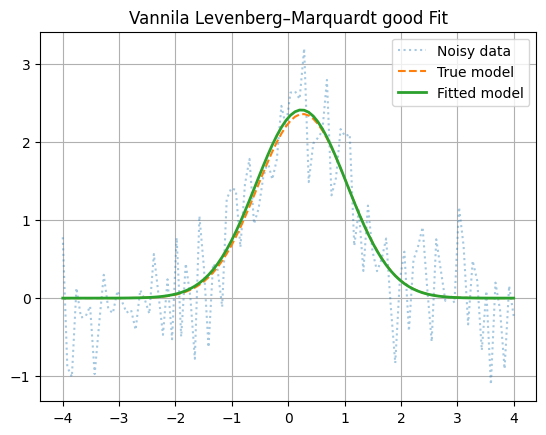

/tmp/ipython-input-170-1835314360.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fitted_params = torch.tensor(fitted_params)


Initial guess: tensor([5.5000, 0.0000, 0.5500])
Fitted parameters: tensor([[ 9.2674, -1.0330,  1.5335]])
True parameters: [ 8.455506   -0.88274187  0.2801536 ]


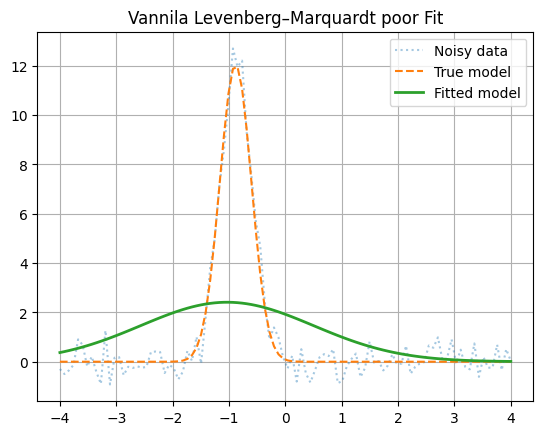

In [ ]:
# --- Run LM manually ---
# good fit
x_axis = torch.linspace(-4, 4, n)

x_exm, s_exm = test_loader.dataset.__getitem__(0)  # x_exm: (100,), s_exm: (3,)

initial_guess = torch.tensor([5.5, 0, 0.55]) # expected value of each parameter

fitted_params = levenberg_marquardt(x_axis.unsqueeze(0), x_exm.unsqueeze(0), initial_guess, max_iter=5)

print("Initial guess:", initial_guess)
print("Fitted parameters:", fitted_params)
print("True parameters:", s_exm.numpy())

x_axis = x_axis if isinstance(x_axis, torch.Tensor) else torch.tensor(x_axis)
x_exm = x_exm if isinstance(x_exm, torch.Tensor) else torch.tensor(x_exm)
s_exm = s_exm if isinstance(s_exm, torch.Tensor) else torch.tensor(s_exm)
fitted_params = torch.tensor(fitted_params)

# Plot
plt.plot(x_axis, x_exm, ':', alpha=0.4, label='Noisy data')
plt.plot(x_axis, true_gaussian(x_axis.unsqueeze(0), s_exm[0:1], s_exm[1:2], s_exm[2:3]).squeeze(0), '--', label='True model')
plt.plot(x_axis, true_gaussian(x_axis.unsqueeze(0), fitted_params[:,0], fitted_params[:,1], fitted_params[:,2]).squeeze(0), label='Fitted model', lw=2)
plt.legend()
plt.title("Vannila Levenberg–Marquardt good Fit")
plt.grid()
plt.show()

# poor fit
x_exm, s_exm = test_loader.dataset.__getitem__(2)  # x_exm: (100,), s_exm: (3,)


fitted_params = levenberg_marquardt(x_axis.unsqueeze(0), x_exm.unsqueeze(0), initial_guess, max_iter=5)

print("Initial guess:", initial_guess)
print("Fitted parameters:", fitted_params)
print("True parameters:", s_exm.numpy())

x_axis = x_axis if isinstance(x_axis, torch.Tensor) else torch.tensor(x_axis)
x_exm = x_exm if isinstance(x_exm, torch.Tensor) else torch.tensor(x_exm)
s_exm = s_exm if isinstance(s_exm, torch.Tensor) else torch.tensor(s_exm)
fitted_params = torch.tensor(fitted_params)

# Plot
plt.plot(x_axis, x_exm, ':', alpha=0.4, label='Noisy data')
plt.plot(x_axis, true_gaussian(x_axis.unsqueeze(0), s_exm[0:1], s_exm[1:2], s_exm[2:3]).squeeze(0), '--', label='True model')
plt.plot(x_axis, true_gaussian(x_axis.unsqueeze(0), fitted_params[:,0], fitted_params[:,1], fitted_params[:,2]).squeeze(0), label='Fitted model', lw=2)
plt.legend()
plt.title("Vannila Levenberg–Marquardt poor Fit")
plt.grid()
plt.show()

In [ ]:
class UnfoldedLM_Model(nn.Module):
    def __init__(self, n_params, T=5, alpha_init=10 , damping_min=1e-6, lamb_init=1e-2):
        super(UnfoldedLM_Model, self).__init__()
        self.n_params = n_params  # Number of parameters to estimate (e.g., 3 for Gaussian: A, mu, sigma)
        self.T = T  # Number of LM iterations (unfolded steps)

        # Learnable diagonal lambda matrices for each iteration (damping factor)
        self.alpha = nn.Parameter(torch.ones(T-1) * alpha_init, requires_grad=True)


    def forward(self, x, params_init, y, residual_fn, jacobian_fn):
        """
        x: (batch_size, n)
        params_init: (batch_size, m)
        y: (batch_size, n)
        residual_fn: function(x, params, y) -> (batch_size, n)
        jacobian_fn: function(x, params) -> (batch_size, n, m)
        """
        batch_size, m = params_init.shape
        device = x.device

        # Initialize lambda per sample
        lambd = torch.full((batch_size, 1, 1), 1e-2, dtype=torch.float32, device=device)
        params = params_init.clone().detach().requires_grad_(True)

        for t in range(self.T):
            r = residual_fn(x, params, y)  # (batch_size, n)
            cost = torch.sum(r ** 2, dim=1, keepdim=True)  # (batch_size, 1)

            J = jacobian_fn(x, params)  # (batch_size, n, m)
            JT = J.transpose(1, 2)      # (batch_size, m, n)
            JTJ = JT @ J                # (batch_size, m, m)

            # λ * I, per sample
            I = torch.eye(m, device=device).unsqueeze(0).expand(batch_size, m, m)

            JTJ_damped = JTJ + lambd * I  # (batch_size, m, m)

            JTr = JT @ r.unsqueeze(-1)    # (batch_size, m, 1)

            try:
                delta = torch.linalg.solve(JTJ_damped, JTr).squeeze(-1)  # (batch_size, m)
            except torch.linalg.LinAlgError:
                print("Singular matrix encountered.")
                break

            new_params = params + delta  # (batch_size, m)
            new_r = residual_fn(x, new_params, y)
            new_cost = torch.sum(new_r ** 2, dim=1, keepdim=True)  # (batch_size, 1)
            delta_cost = new_cost - cost  # (batch_size, 1)

            # Final iteration uses a hard update mask
            if t == self.T - 1:
                mask = 1 - torch.sigmoid(1e3 * delta_cost)  # ~1 if new_cost < cost
                params = new_params * mask + params * (1 - mask)
                break

            # Differentiable update
            alpha = F.softplus(self.alpha[t]) + 1e-4
            factor = torch.tanh(10 * delta_cost).unsqueeze(-1)  # (batch_size, 1,1)
            alpha = alpha.expand_as(factor)

            lambd = (alpha ** factor) * lambd

            lambd = torch.clamp(lambd, min=1e-6, max=1e6)

            mask = 1 - torch.sigmoid(10 * delta_cost)
            params = new_params * mask + params * (1 - mask)




        return params


"\ninitial_params=torch.tensor([5.5, 0, 0.55])\nx_axis = torch.linspace(-4, 4, n)\nmse_model=np.zeros(8)\nmse_lm=np.zeros(8)\n\nfor t in range(2,10):\n  mse_t=0\n  mse_l=0\n  model=UnfoldedLM_Model(n_params=3,T=t)\n  for y,s in test_loader:\n    s_init_model=initial_params.unsqueeze(0).repeat(s.shape[0],1)\n    s_hat_model=model(x_axis.unsqueeze(0).repeat(s.shape[0],1),s_init_model,y,residuals,jacobian)\n    r_model=F.mse_loss(s_hat_model,s,reduction='sum')\n    mse_t+=r_model.data.item()\n\n    s_init=initial_params\n    s_hat=levenberg_marquardt(x_axis.unsqueeze(0).repeat(s.shape[0],1),y,s_init,max_iter=t)\n    r_lm=F.mse_loss(s_hat,s,reduction='sum')\n    mse_l+=r_lm.data.item()\n\n  mse_model[t-2]=mse_t/len(test_loader.dataset)\n  mse_lm[t-2]=mse_l/len(test_loader.dataset)\n  print('T= ',t, 'mse_model= ',mse_model[t-2])\n  print('T= ',t, 'mse_lm= ',mse_lm[t-2])\n"

In [ ]:
def train_unfolded_lm(model, train_loader, valid_loader, residual_fn, jacobian_fn, num_epochs=50, lr=1e-04):
    """
    Train the UnfoldedLM_Model using SimulatedData DataLoader.

    Args:
        model: the UnfoldedLM_Model
        train_loader: PyTorch DataLoader for training
        valid_loader: PyTorch DataLoader for validation
        residual_fn: function for computing residuals
        jacobian_fn: function for computing Jacobians
        num_epochs: number of epochs
        lr: learning rate

    Returns:
        loss_valid: validation losses per epoch
    """
    x_axis = torch.linspace(-4, 4, 100)  # n should be 100 as defined previously
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,weight_decay=0)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

    loss_train = np.zeros((num_epochs,))
    loss_valid = np.zeros((num_epochs,))

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0


        for y_batch, s_batch in train_loader:
            label= true_gaussian(x_axis.unsqueeze(0).repeat(s_batch.shape[0], 1), s_batch[:, 0], s_batch[:, 1], s_batch[:, 2])
            batch_size = s_batch.shape[0]
            A_init     = 5.5 * torch.ones(batch_size)
            mu_init    =  torch.zeros(batch_size)
            sigma_init = 0.55 * torch.ones(batch_size)

            s_init = torch.stack([A_init, mu_init, sigma_init], dim=1)  # Shape: (batch_size, 3)

            # Forward pass
            s_hat = model(x_axis.unsqueeze(0).repeat(batch_size, 1), s_init, y_batch, residual_fn, jacobian_fn)  # (batch_size, 3)

            # Predict signal from estimated parameters
            y_hat = true_gaussian(x_axis.unsqueeze(0).repeat(s_hat.shape[0], 1), s_hat[:, 0], s_hat[:, 1], s_hat[:, 2])

            # Compute loss between predicted signal and true signal
            loss = F.mse_loss(s_hat, s_batch, reduction="sum")
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        loss_train[epoch] = train_loss / (len(train_loader.dataset))
        scheduler.step()

        # Validation
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for  y_batch, s_batch in test_loader:

                label= true_gaussian(x_axis.unsqueeze(0).repeat(s_batch.shape[0], 1), s_batch[:, 0], s_batch[:, 1], s_batch[:, 2])
                batch_size = s_batch.shape[0]
                A_init     = 5.5 * torch.ones(batch_size)
                mu_init    =  torch.zeros(batch_size)
                sigma_init = 0.55 * torch.ones(batch_size)

                s_init = torch.stack([A_init, mu_init, sigma_init], dim=1)  # Shape: (batch_size, 3)

                s_hat = model(x_axis.unsqueeze(0).repeat(s_batch.shape[0], 1), s_init, y_batch, residual_fn, jacobian_fn)
                '''y_hat = true_gaussian(x_axis.unsqueeze(0).repeat(s_hat.shape[0], 1), s_hat[ 0], s_hat[ 1], s_hat[ 2])'''
                loss = F.mse_loss(s_hat, s_batch, reduction='sum')
                valid_loss += loss.data.item()

        loss_valid[epoch] = valid_loss / len(valid_loader.dataset)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss = {loss_train[epoch]:.6f}, Validation Loss = {loss_valid[epoch]:.6f}")

    print("Training complete.")
    print(f"Final Train Loss = {loss_train[-1]:.6f}, Validation Loss = {loss_valid[-1]:.6f}")


    return loss_valid, y_batch, s_batch



In [ ]:
def llm_apply(train_loader, test_loader, T, residual_fn, jacobian_fn):

    model = UnfoldedLM_Model(n_params=3, T=T)
    loss_test,b_y,b_s = train_unfolded_lm(model, train_loader, test_loader, residuals, jacobian)
    err_list = loss_test[-1]

    return err_list, model, b_y, b_s


def vanilla_lm_apply(test_loader, T, x_axis,initial_params):

    valid_loss = 0
    loss=0

    for  y, s in test_loader:

        s_hat = levenberg_marquardt(x_axis.unsqueeze(0).repeat(s.shape[0], 1), y, initial_params, max_iter=T)
        # Convert the list s_hat to a tensor before calculating loss

        loss = F.mse_loss(s_hat, s, reduction='sum')
        valid_loss += loss.data.item()

    return valid_loss / len(test_loader.dataset)

In [ ]:
def plot_vanilla_lm_vs_llm_reconstruction(s_hat_vanilla, s_hat_llm, T, s_gt,x_axis):
    plt.figure()
    plt.subplot(2, 1, 1)
    # plt.title("L-LM K={0}".format(T), fontsize=10)

    s_hat_llm = s_hat_llm.unsqueeze(0)  # now shape is (1, 3)
    s_gt = s_gt.unsqueeze(0)  # now shape is (1, 3)
    s_hat_vanilla=s_hat_vanilla
    x_input = x_axis.unsqueeze(0)      # (1, n)

    plt.plot(x_axis,true_gaussian(x_input, s_hat_llm[:, 0], s_hat_llm[:, 1], s_hat_llm[:, 2]).squeeze(), '.--', label='L-LM, K={0}'.format(T), color='r', linewidth=1)
    plt.plot(x_axis,true_gaussian(x_input, s_gt[:, 0], s_gt[:, 1], s_gt[:, 2]).squeeze(), label='True model', color='k')

    plt.xlabel('Index', fontsize=10)
    plt.ylabel('Value', fontsize=10)
    plt.legend()
    axs1 = plt.subplot(2, 1, 2)

    new_pos = axs1.get_position()
    new_pos.y0 -= 0.15 * new_pos.y0
    new_pos.y1 -= 0.15 * new_pos.y1
    axs1.set_position(pos=new_pos)

    plt.plot(x_axis,true_gaussian(x_axis, s_hat_vanilla[:, 0], s_hat_vanilla[:, 1], s_hat_vanilla[:, 2]).squeeze(), '.--', label='Vanilla LM, K={0}'.format(T), color='r', linewidth=1)
    plt.plot(x_axis,true_gaussian(x_input, s_gt[:, 0], s_gt[:, 1], s_gt[:, 2]).squeeze(), label='True model', color='k')

    plt.xlabel('Index', fontsize=10)
    plt.ylabel('Value', fontsize=10)
    plt.legend()
    plt.show()

def plot_vanilla_vs_llm_convergence(T_opt, vanilla_mse, llm_mse):
    plt.figure()
    plt.plot(T_opt, vanilla_mse, label='Vanilla LM', color='b', linewidth=0.5)
    plt.plot(T_opt, llm_mse, label='L-LM', color='r', linewidth=2)
    plt.xlabel('Number of iterations', fontsize=10)
    plt.ylabel('MSE', fontsize=10)
    plt.yscale("log")
    ymin = min(min(vanilla_mse), min(llm_mse))
    ymax = max(max(vanilla_mse), max(llm_mse))
    ticks = np.logspace(np.floor(np.log10(ymin)), np.ceil(np.log10(ymax)), num=6)
    plt.yticks(ticks, [f"{t:.1e}" for t in ticks])

    plt.tick_params(axis='y', which='both', labelsize=8)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()



## Comparing Unfolded LM to vanilla LM

In the following loop we compare LM to trained unfolded LM with different number of iterations.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 0: Train Loss = 0.971715, Validation Loss = 1.032279
Epoch 10: Train Loss = 0.971715, Validation Loss = 1.032279
Epoch 20: Train Loss = 0.971715, Validation Loss = 1.032279
Epoch 30: Train Loss = 0.971715, Validation Loss = 1.032279
Epoch 40: Train Loss = 0.971715, Validation Loss = 1.032279
Training complete.
Final Train Loss = 0.971715, Validation Loss = 1.032279
alpha: tensor([9.9989])


/tmp/ipython-input-187-672207032.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_hat_vanilla = torch.tensor(s_hat_vanilla) # Convert to tensor for plotting


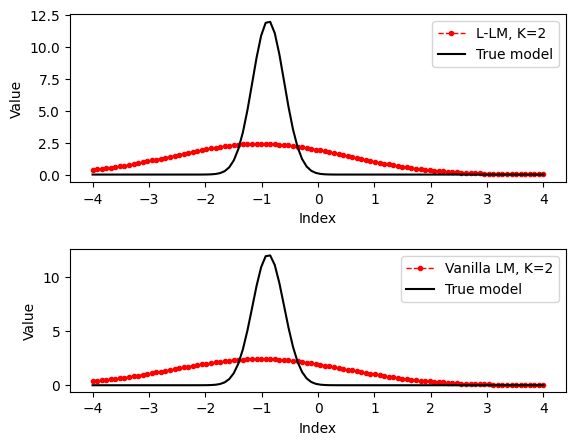

Epoch 0: Train Loss = 0.872921, Validation Loss = 0.959229
Epoch 10: Train Loss = 0.872672, Validation Loss = 0.958712
Epoch 20: Train Loss = 0.871992, Validation Loss = 0.958381
Epoch 30: Train Loss = 0.872604, Validation Loss = 0.958408
Epoch 40: Train Loss = 0.872287, Validation Loss = 0.958545
Training complete.
Final Train Loss = 0.872004, Validation Loss = 0.958577
alpha: tensor([10.0004, 10.0022,  9.9984])


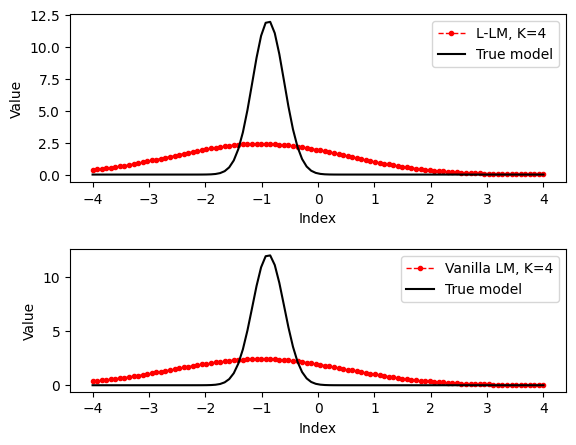

Epoch 0: Train Loss = 0.659953, Validation Loss = 0.774793
Epoch 10: Train Loss = 0.659493, Validation Loss = 0.780321
Epoch 20: Train Loss = 0.727523, Validation Loss = 0.703393
Epoch 30: Train Loss = 0.711663, Validation Loss = 0.682814
Epoch 40: Train Loss = 0.713336, Validation Loss = 0.699702
Training complete.
Final Train Loss = 0.712520, Validation Loss = 0.702833
alpha: tensor([419.8053,   9.4880,   9.4832,   9.9533,  10.0002])


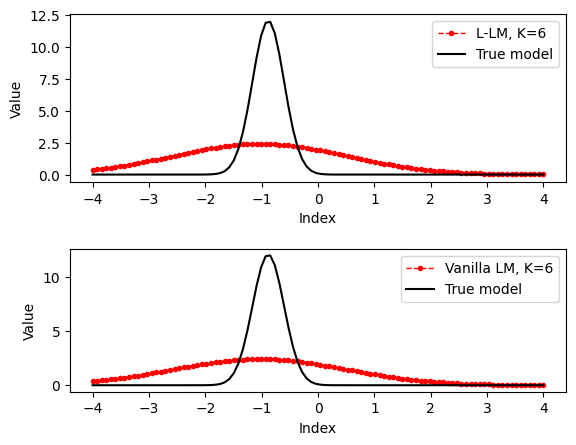

Epoch 0: Train Loss = 0.432869, Validation Loss = 0.467958
Epoch 10: Train Loss = 0.384591, Validation Loss = 0.338078
Epoch 20: Train Loss = 0.368563, Validation Loss = 0.345467
Epoch 30: Train Loss = 0.358878, Validation Loss = 0.351593
Epoch 40: Train Loss = 0.367576, Validation Loss = 0.337780
Training complete.
Final Train Loss = 0.370884, Validation Loss = 0.348456
alpha: tensor([1161.5079,   58.0318,    9.3202,    9.2196,    9.2271,   10.2970,
           9.9312])


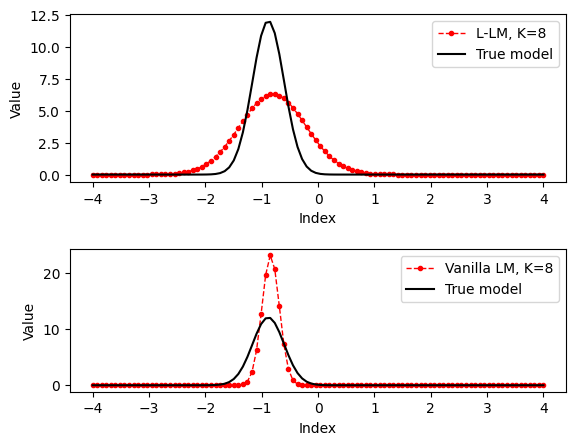

Epoch 0: Train Loss = 0.243308, Validation Loss = 0.300083
Epoch 10: Train Loss = 0.287569, Validation Loss = 0.311700
Epoch 20: Train Loss = 0.275635, Validation Loss = 0.256124
Epoch 30: Train Loss = 0.316101, Validation Loss = 0.258259
Epoch 40: Train Loss = 0.204360, Validation Loss = 0.183273
Training complete.
Final Train Loss = 0.220732, Validation Loss = 0.192552
alpha: tensor([1237.7041,  105.2826,   10.9199,    4.9415,    4.6139,    9.9216,
           9.2176,   10.0834,   10.0545])


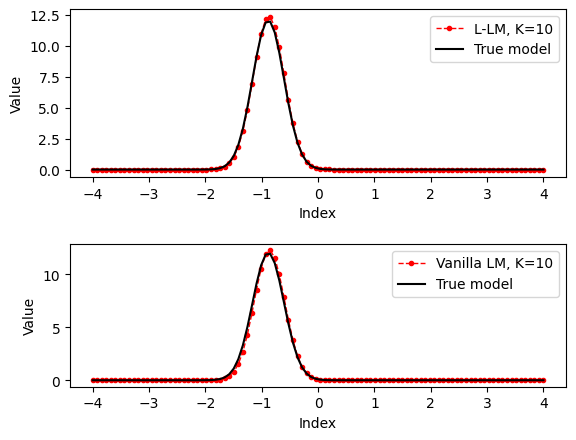

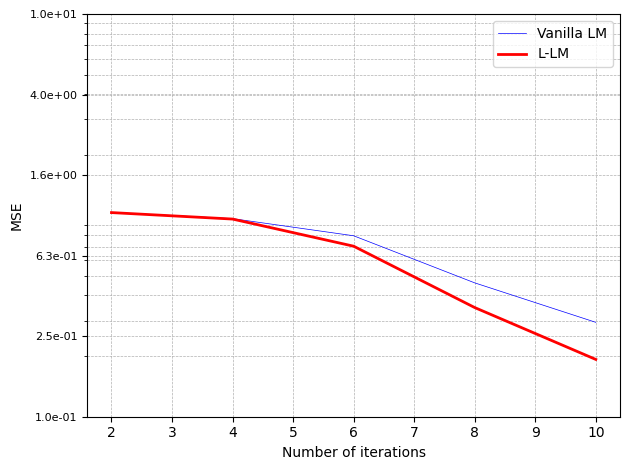

In [ ]:
# save path
from google.colab import drive
drive.mount('/content/drive')
save_path='/content/drive/MyDrive/Colab Notebooks/saved_models'

# Number of unfoldings


tstart, tend, tstep = 2, 11, 2
T_opt = range(tstart, tend, tstep)

vanilla_mse = []
llm_mse = []

for i, T in enumerate(T_opt):

    # Train and apply model based LLM
    err_lst, k_l_lm, b_y, b_s = llm_apply(train_loader, test_loader, T, residuals, jacobian)
    torch.save(k_l_lm.state_dict(), f"{save_path}/model_T_{T}.pt")
    llm_mse.append(err_lst)
    for name, param in k_l_lm.named_parameters():
        if param.requires_grad:
           print(f"{name}: {param.data}")

    # Apply vanilla LLM
    vanilla_mse_T=vanilla_lm_apply(test_loader, T, x_axis, torch.tensor([5.5, 0, 0.55]))
    vanilla_mse.append(vanilla_mse_T)


    ######################### Visualization #########################

    # Visualize performance of a single signal from the validation batches b_x, b_s
    # Select a single example from the batch for plotting
    example_index = 2
    y_single, s_gt_single = test_loader.dataset.__getitem__(example_index)

    A_init     = 5.5 * torch.ones(1)
    mu_init    =  torch.zeros(1)
    sigma_init = 0.55 * torch.ones(1)

    s_init = torch.stack([A_init, mu_init, sigma_init], dim=1)  # Shape: (1, 3)

    s_hat_llm = k_l_lm(x_axis.unsqueeze(0), s_init, y_single.unsqueeze(0), residuals, jacobian)
    s_hat_llm = s_hat_llm.detach().squeeze(0) # Remove batch dimension and detach

    # For vanilla LM
    s_hat_vanilla = levenberg_marquardt(x_axis.unsqueeze(0), y_single.unsqueeze(0), torch.tensor([5.5, 0, 0.55]), max_iter=T)
    s_hat_vanilla = torch.tensor(s_hat_vanilla) # Convert to tensor for plotting
    plot_vanilla_lm_vs_llm_reconstruction(s_hat_vanilla=s_hat_vanilla,
                                      s_hat_llm=s_hat_llm, T=k_l_lm.T, s_gt=s_gt_single.squeeze(0),x_axis=x_axis)


plot_vanilla_vs_llm_convergence(T_opt,vanilla_mse, llm_mse)

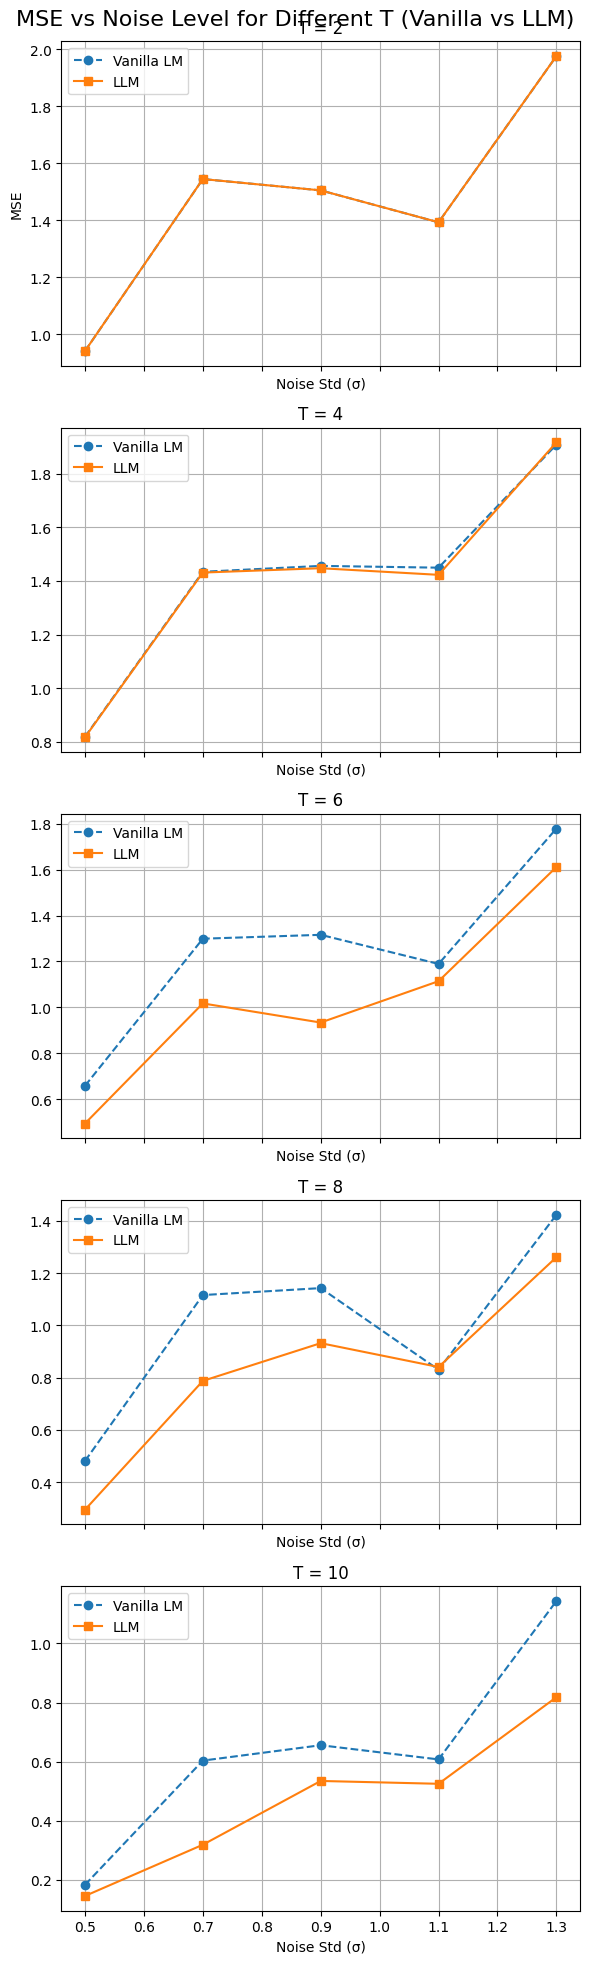

In [ ]:
# uploading the saved models and testeing them versus different noise variance:
sigma_v = [0.5, 0.7 ,0.9 ,1.1, 1.3]
llm_mse_perV = []
vanilla_mse_perV = []

# initial params
s_init = torch.tensor([5.5, 0, 0.55])

for sigma in sigma_v:
    # Reset MSE lists per T for this sigma
    llm_mse_perT = []
    vanilla_mse_perT = []

    # smaller data set with given noise
    test_loader = create_data_set(n=100, N=100, sigma_v=sigma, batch_size=64)

    for t in range(2, 11, 2):  # T = 2,4,6,8,10
        llm_mse = 0
        vanilla_mse = 0

        # Load model
        model = UnfoldedLM_Model(n_params=3, T=t)
        model.load_state_dict(torch.load(f"{save_path}/model_T_{t}.pt"))
        model.eval()

        # Calculate MSE on test set
        for y_batch, s_batch in test_loader:
            batch_size = s_batch.shape[0]

            s_hat_llm = model(
                x_axis.unsqueeze(0).repeat(batch_size, 1),
                s_init.unsqueeze(0).repeat(batch_size, 1),
                y_batch,
                residuals,
                jacobian
            )

            s_hat_vanilla = levenberg_marquardt(
                x_axis.unsqueeze(0).repeat(batch_size, 1),
                y_batch,
                s_init,
                max_iter=t
            )

            llm_mse += F.mse_loss(s_hat_llm, s_batch, reduction='sum').item()
            vanilla_mse += F.mse_loss(s_hat_vanilla, s_batch, reduction='sum').item()

        # Average over dataset
        llm_mse_perT.append(llm_mse / len(test_loader.dataset))
        vanilla_mse_perT.append(vanilla_mse / len(test_loader.dataset))

    # Append results per sigma
    llm_mse_perV.append(llm_mse_perT)
    vanilla_mse_perV.append(vanilla_mse_perT)


sigma_v = np.array(sigma_v)
T_list = list(range(2, 11, 2))  # T = 2, 4, 6, 8, 10

llm_mse_perV = np.array(llm_mse_perV)           # shape: (len(sigma_v), len(T_list))
vanilla_mse_perV = np.array(vanilla_mse_perV)   # same shape

# Transpose so each row is fixed T, columns over sigma_v
llm_mse_perV = llm_mse_perV.T
vanilla_mse_perV = vanilla_mse_perV.T

# Plot
fig, axs = plt.subplots(len(T_list),1,figsize=(6, 4 * len(T_list)), sharex=True)

for i, T in enumerate(T_list):
    ax = axs[i]
    ax.plot(sigma_v, vanilla_mse_perV[i], 'o--', label='Vanilla LM')
    ax.plot(sigma_v, llm_mse_perV[i], 's-', label='LLM')
    ax.set_title(f"T = {T}")
    ax.set_xlabel("Noise Std (σ)")
    if i == 0:
        ax.set_ylabel("MSE")
    ax.grid(True)
    ax.legend()

plt.suptitle("MSE vs Noise Level for Different T (Vanilla vs LLM)", fontsize=16)
plt.tight_layout()
plt.show()


/tmp/ipython-input-262-538821768.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_hat_vanilla = torch.tensor(s_hat_vanilla) # Convert to tensor for plotting


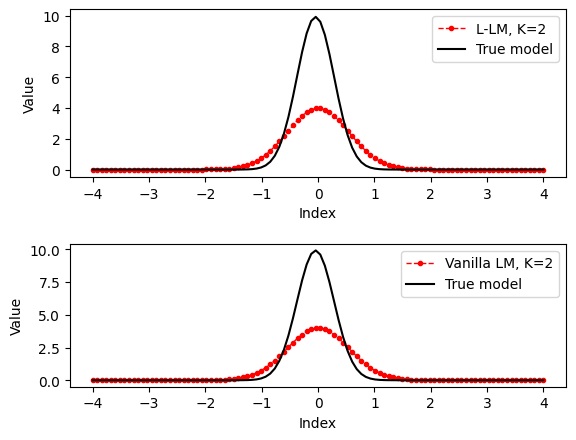

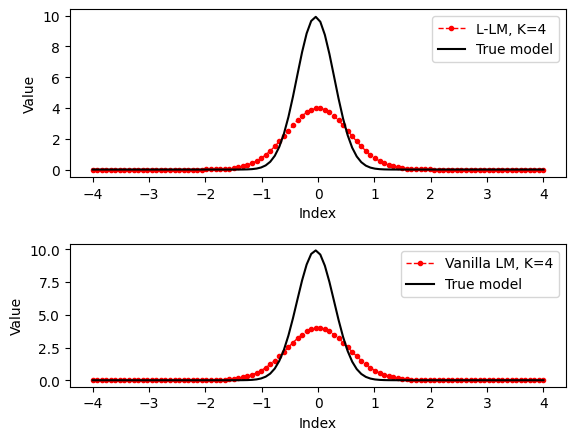

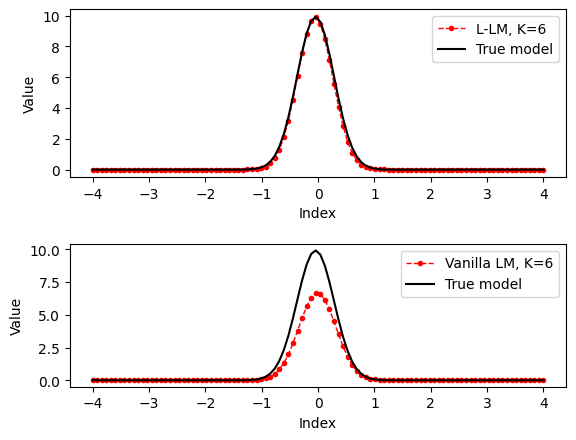

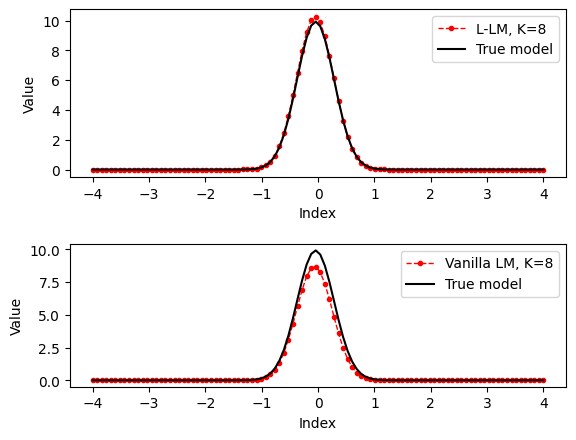

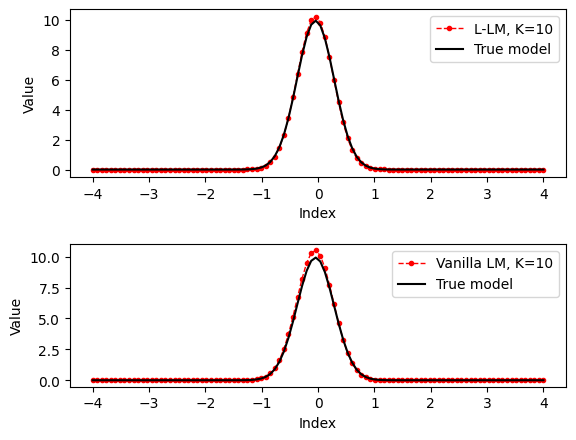

In [ ]:
example_index = 4
y_single, s_gt_single = test_loader.dataset.__getitem__(example_index)

A_init     = 5.5 * torch.ones(1)
mu_init    =  torch.zeros(1)
sigma_init = 0.55 * torch.ones(1)

s_init = torch.stack([A_init, mu_init, sigma_init], dim=1)  # Shape: (1, 3)
for t in range(2, 11, 2):  # T = 2,4,6,8,10


    # Load model
    model = UnfoldedLM_Model(n_params=3, T=t)
    model.load_state_dict(torch.load(f"{save_path}/model_T_{t}.pt"))
    model.eval()
    s_hat_llm = model(x_axis.unsqueeze(0), s_init, y_single.unsqueeze(0), residuals, jacobian)
    s_hat_llm = s_hat_llm.detach().squeeze(0) # Remove batch dimension and detach

    # For vanilla LM
    s_hat_vanilla = levenberg_marquardt(x_axis.unsqueeze(0), y_single.unsqueeze(0), torch.tensor([5.5, 0, 0.55]), max_iter=t)
    s_hat_vanilla = torch.tensor(s_hat_vanilla) # Convert to tensor for plotting
    plot_vanilla_lm_vs_llm_reconstruction(s_hat_vanilla=s_hat_vanilla,
                                      s_hat_llm=s_hat_llm, T=model.T, s_gt=s_gt_single.squeeze(0),x_axis=x_axis)
